In [9]:
import numpy as np
import modules.tools as tools
from numpy import cos, sin, pi, exp, sqrt, sinh
import scipy.integrate as integrate
from numpy.linalg import norm
import copy

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

In [11]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

In [12]:
from tqdm.notebook import tqdm # to have a progress bar for the loop

In [13]:
from functools import partial

In [14]:
import os
import pickle
print(os.path.dirname(os.getcwd()))

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band/Zenodo


## Read data of DFT bands

In [15]:
# data that contains the exact DFT bands
data_DFT = []

f = open('DFT_data/wannier90_band.dat','r')
lines = f.readlines()
data_DFT = []
for x in lines:
    data_DFT.append(x)
f.close()

In [16]:
# separate the lines into columns
# there are two data sets separated by an empty line

# data set 1
ks_DFT_1 = []
Es_DFT_1 = []

# data set 2
ks_DFT_2 = []
Es_DFT_2 = []

empty_line = 0
for line in data_DFT:
    columns = line.split() # split line string into separate words
    
    if len(columns)==0:
        empty_line += 1
        continue
        
    if empty_line == 0:
        ks_DFT_1.append(float(columns[0]))
        Es_DFT_1.append(float(columns[1]))
    elif empty_line == 1:
        ks_DFT_2.append(float(columns[0]))
        Es_DFT_2.append(float(columns[1]))
    else:
        break

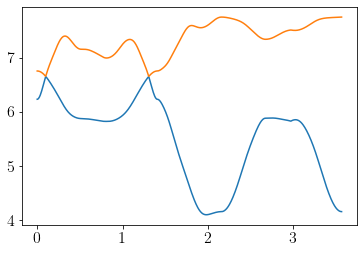

In [17]:
plt.plot(ks_DFT_1, Es_DFT_1)
plt.plot(ks_DFT_2, Es_DFT_2)

## Read hopping data

In [20]:
# data that contains the hopping amplitudes of the tight-binding model
data_hop = []

f = open('DFT_data/wannier90_hr.dat','r')
lines = f.readlines()
data_hop = []
for x in lines:
    data_hop.append(x)
f.close()

In [21]:
len(data_hop)

11476

In [22]:
# separate the lines into columns

hoppings = []

for line in data_hop:
    columns = line.split() # split line string into separate words
    hopping = []
    # convert strings to integers and floats, ignore last column
    hopping.append(int(columns[0]))
    hopping.append(int(columns[1]))
    hopping.append(int(columns[2]))
    hopping.append(int(columns[3]))
    hopping.append(int(columns[4]))
    hopping.append(float(columns[5]))
    # add to hoppings
    hoppings.append(hopping)

In [23]:
hoppings_arr = np.array(hoppings)

In [24]:
# sort hopping terms by magnitude in descending order
hoppings_sorted = hoppings_arr[np.argsort(abs(hoppings_arr[:, 5]))[::-1]]

In [25]:
print(len(hoppings_sorted[:,0]))

11476


In [26]:
hopping_data0 = hoppings_sorted[0:204,:] # cut-off at 6meV
#hopping_data0 = hoppings_sorted[0:216,:]
#hopping_data = hoppings_sorted[0:12,:]

In [27]:
%precision 8
print(hopping_data0[-10:,:])

[[ 1.        1.        2.        2.        1.        0.007119]
 [-1.       -1.       -2.        1.        2.        0.007119]
 [ 1.        1.       -3.        1.        2.       -0.006505]
 [-1.       -1.       -2.        2.        1.        0.006505]
 [-1.       -1.        3.        2.        1.       -0.006505]
 [ 1.        1.        2.        1.        2.        0.006505]
 [-1.       -1.       -3.        1.        2.        0.006138]
 [ 1.        1.        3.        2.        1.        0.006138]
 [-1.       -1.        2.        1.        2.       -0.006137]
 [ 1.        1.       -2.        2.        1.       -0.006137]]


Each row is of the form $[(x,y,z), l, m, t]$ corresponding to hopping from an orbital $l$ at $(0,0,0)$ to an orbital $m$ at $(x,y,z)$, where $(x,y,z)$ is with respect to the primitive lattice vectors.

## Construct tight-binding Hamiltonian

In [28]:
def hamiltonian_full(kx,ky,kz, hopping_data):
    
    a1 = np.array([7.045, 0., 0.])
    a2 = np.array([-3.5225, 6.101149, 0.])
    a3 = np.array([0., 0., 4.174])
    r_basis = np.array([a1,a2,a3])
    
    r_sp = (np.array([1/3, 1/3, 0]) - np.array([0, 0, 1/2])) @ r_basis # separation vector from p to s
    k = np.array([kx,ky,kz])
            
    H = np.zeros((2,2), dtype=complex)
    
    for hop in hopping_data:             
        i = int(hop[3])-1
        j = int(hop[4])-1
        dr = np.array([hop[0],hop[1],hop[2]]) @ r_basis + r_sp*(j-i)
        t = hop[5]
        H[i,j] += t * exp(-1.j*k@dr)
    
    return H

In [29]:
def count_hopping_parameters(hopping_data):
    counter = 0
    parameters = []
    for hop in hopping_data:
        exists = False
        t = hop[5]
        for param in parameters:
            if abs(t)==abs(param):
                exists = True
                break
        if exists==False: 
            parameters.append(abs(t))
            counter += 1
    return parameters, counter       

In [30]:
def eliminate_rounding_errors(hopping_data, err=1e-5):
    ''' The DFT Wannier fit does not fully impose the symmetries of the system,
        which is why certain parameters, which should be identical by symmetry, 
        can come out different by a rounding error err. This function detects
        these rounding errors and returns a corrected hopping parameter array.
        
    '''
    hop_data = copy.deepcopy(hopping_data)
    parameters = []
    for i,hop in enumerate(hop_data):
        exists = False
        t = hop[5]
        for param in parameters:
            if abs(t) <= (abs(param)+err) and abs(t) >= (abs(param)-err):
                exists = True
                hop_data[i,5] = np.sign(t)*abs(param)
                break
        if exists==False: 
            parameters.append(abs(t))
    return hop_data

In [31]:
# check hermiticity at random momentum
kx = 2*np.random.random_sample()-1
ky = 2*np.random.random_sample()-1
kz = 2*np.random.random_sample()-1

# best results
#hopping_data0 = hoppings_sorted[0:642,:]

# hopping range in x-y plane below 3 unit cells along any primitive lattice vectors
#hopping_data0 = hoppings_sorted[0:216,:]

# hopping range in x-y plane below 3 unit cells along any primitive lattice vectors and energy cut-off 6meV
hopping_data0 = hoppings_sorted[0:204,:]

different_params0, counter0 = count_hopping_parameters(hopping_data0)
print(counter0)
print(hamiltonian_full(kx,ky,kz,hopping_data0) - np.transpose(np.conj(hamiltonian_full(kx,ky,kz,hopping_data0))))

87
[[0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]


In [32]:
hopping_data = eliminate_rounding_errors(hopping_data0, 2e-4)

different_params, counter = count_hopping_parameters(hopping_data)
print(counter)

37


In [33]:
%precision 8
print(hopping_data[-10:,:])

[[ 1.        1.        2.        2.        1.        0.007216]
 [-1.       -1.       -2.        1.        2.        0.007216]
 [ 1.        1.       -3.        1.        2.       -0.006505]
 [-1.       -1.       -2.        2.        1.        0.006505]
 [-1.       -1.        3.        2.        1.       -0.006505]
 [ 1.        1.        2.        1.        2.        0.006505]
 [-1.       -1.       -3.        1.        2.        0.006138]
 [ 1.        1.        3.        2.        1.        0.006138]
 [-1.       -1.        2.        1.        2.       -0.006138]
 [ 1.        1.       -2.        2.        1.       -0.006138]]


In [34]:
print(different_params0)

[7.253113, 5.653606, 0.48426, 0.484259, 0.166297, 0.109529, 0.109527, 0.109522, 0.109518, 0.108437, 0.101905, 0.101901, 0.088303, 0.071834, 0.071828, 0.065723, 0.05558, 0.055577, 0.046484, 0.046483, 0.046481, 0.04648, 0.044973, 0.042299, 0.042296, 0.041902, 0.041901, 0.0419, 0.037731, 0.034545, 0.034542, 0.034541, 0.034043, 0.034041, 0.021146, 0.021078, 0.021043, 0.021042, 0.020624, 0.020623, 0.018827, 0.018824, 0.016435, 0.016307, 0.016306, 0.016242, 0.016241, 0.016211, 0.015958, 0.015957, 0.015955, 0.015171, 0.01517, 0.015168, 0.015149, 0.015144, 0.01329, 0.013288, 0.013285, 0.011089, 0.011087, 0.010876, 0.010875, 0.009963, 0.009962, 0.009143, 0.009142, 0.008899, 0.008898, 0.008897, 0.008481, 0.00848, 0.008321, 0.00832, 0.008319, 0.008269, 0.008004, 0.008003, 0.008001, 0.007216, 0.007161, 0.00716, 0.00712, 0.007119, 0.006505, 0.006138, 0.006137]


In [35]:
print(different_params)

[7.253113, 5.653606, 0.48426, 0.166297, 0.109529, 0.108437, 0.101905, 0.088303, 0.071834, 0.065723, 0.05558, 0.046484, 0.044973, 0.042299, 0.041902, 0.037731, 0.034545, 0.034043, 0.021146, 0.020624, 0.018827, 0.016435, 0.016211, 0.015958, 0.015171, 0.01329, 0.011089, 0.010876, 0.009963, 0.009143, 0.008899, 0.008481, 0.008269, 0.008004, 0.007216, 0.006505, 0.006138]


In [36]:
print(min(np.array(different_params[2:-1])-np.array(different_params[3:])))

0.00021200000000000038


In [37]:
# show maximum hopping distances along lattice vectors
print(max(hopping_data[:,0]))
print(max(hopping_data[:,1]))
print(max(hopping_data[:,2]))

2.0
2.0
6.0


In [38]:
# reciprocal lattice vectors (hexagonal system)
b1 = np.array([0.891864, 0.514918, 0])
b2 = np.array([0, 1.029836, 0])
b3 = np.array([0, 0, 1.505315])
k_basis = np.array([b1,b2,b3]) # Wannier-90 uses a different reciprocal basis

In [39]:
# define high-symmetry points for the band plot
Gamma = np.array([0,0,0]) @ k_basis
A = np.array([0,0,1/2]) @ k_basis
K = np.array([1/3,1/3,0]) @ k_basis
H = np.array([1/3,1/3,1/2]) @ k_basis
M = np.array([0,1/2,0]) @ k_basis
L = np.array([0,1/2,1/2]) @ k_basis

k_points = [Gamma, M, K, Gamma, A, L, H, A]
k_labels = ['$\Gamma$', '$M$', '$K$', '$\Gamma$', '$A$', '$L$', '$H$', '$A$']

In [40]:
# model with 37 parameters
k_line_bulk ,energies_bulk, evecs_bulk = tools.compute_bands_3D(hamiltonian_full, dict(hopping_data=hopping_data), 
                                                             k_points, Nk=100)

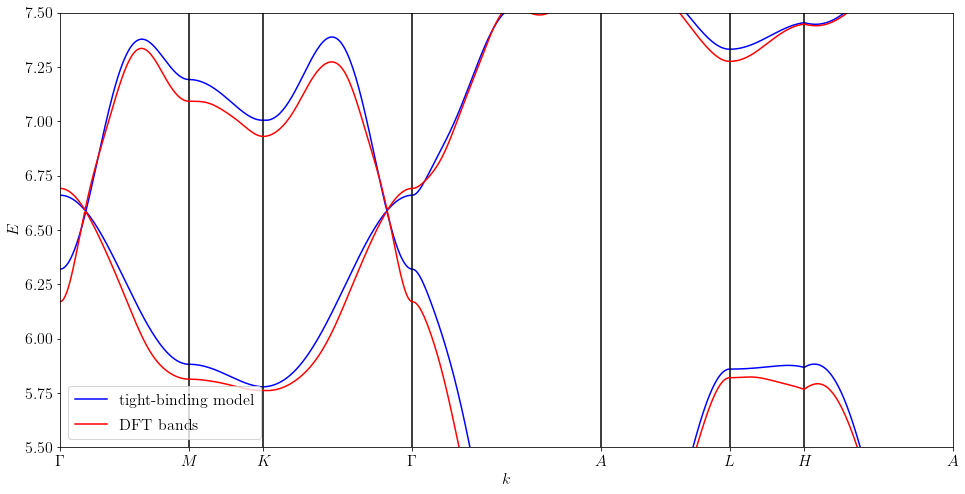

In [41]:
tools.plot_bands_3D(k_line_bulk, energies_bulk, k_labels, ymin=5.5, ymax=7.5, 
                                                             linecolor='b', label='tight-binding model',figsize=(16,8))
plt.plot(ks_DFT_1, np.array(Es_DFT_1)-0.06, c='r', label='DFT bands')
plt.plot(ks_DFT_2, np.array(Es_DFT_2)-0.06, c='r')

plt.legend(loc=3)

### Plot several $k_z$ cuts parallel K-Gamma-M

In [42]:
Ncuts = 21
kzs = np.linspace(-b3[2]/2, 0, Ncuts, endpoint=True) 

klines = []
energy_cuts = []

for i,kz in tqdm(list(enumerate(kzs))):
    kz_vec = np.array([0,0,kz])
    k_points = [K + kz_vec, Gamma + kz_vec, M + kz_vec]
    # model with 37 parameters
    kline, energies, evecs = tools.compute_bands_3D(hamiltonian_full, dict(hopping_data=hopping_data), 
                                                             k_points, Nk=100)
    klines.append(kline)
    energy_cuts.append(energies - 6.582) 

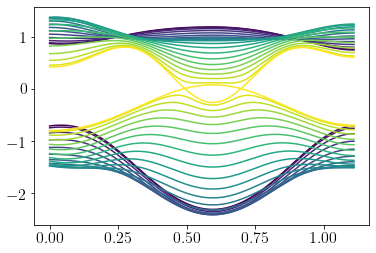

In [43]:
import matplotlib.colors as colors
import matplotlib.cm as cm

cmap = plt.get_cmap('viridis') 
cNorm  = colors.Normalize(vmin=kzs[0], vmax=kzs[-1])
scalarMap = cm.ScalarMappable(norm=cNorm, cmap=cmap)

for i in range(Ncuts):
    colorVal = scalarMap.to_rgba(kzs[i])
    plt.plot(klines[0],energy_cuts[i], color=colorVal)

#### Save to file for figures

In [733]:
# Write everything to a pickle file
#path = os.path.dirname(os.getcwd()) + '/data/'
#out_name = 'CaAgP_bulk-band_cuts'
#fp = open(path + out_name + '.p', 'wb')
pickle.dump(kzs, fp)
pickle.dump(klines[0], fp)
pickle.dump(energy_cuts, fp)
#fp.close()

## 37-parameter model in slab geometry

In [44]:
def hamiltonian_strained_slab(kx, ky, Lz, R, mu, hopping_data, alpha=0.0, termination='sp'):
    
    a1 = np.array([7.045, 0.])
    a2 = np.array([-3.5225, 6.101149])
    b = 4.174
    
    rxy_basis = np.array([a1,a2])
    
    # separation vector from p to s projected into xy plane
    rxy_sp = (np.array([1/3, 1/3])) @ rxy_basis
    k = np.array([kx,ky])
            
    if termination == 'ps': 
        z0 = -Lz*b/2 -b/4
        Lz+=1 
    elif termination == 'p': 
        z0 = -Lz*b/2 - b/2
        Lz+=1 
    elif termination == 's': 
        z0 = -Lz*b/2 
        Lz+=1 
    elif termination == 'sp': 
        z0 = -Lz*b/2 + b/4
    else:
        # assume sp by default
        z0 = z0 = -Lz*b/2 + b/4
    
    H = np.zeros((2*Lz,2*Lz), dtype=complex)
         
    for hop in hopping_data: 
        l = int(hop[3])-1 # initial state
        m = int(hop[4])-1 # final state
        dr = (np.array([hop[0],hop[1]]) @ rxy_basis) + rxy_sp*(l-m)
        dz = int(hop[2])
        hop_length = sqrt(dr@dr + (dz*b + 0.5*(m-l)*b)**2)
        x = dr[0]*cos(alpha) + dr[1]*sin(alpha)
        t = hop[5]
        
        if dz > 0: # blocks in lower triangle
            for i in range(Lz-dz):
                z_av = ((z0 + i*b + l*b/2) + (z0 + (i+dz)*b + m*b/2))/2  
                H[2*(i+dz)+m, 2*i+l] += (t * exp(-1.j*k@dr) *
                                          (1. - (z_av/R * x**2/hop_length**2)))
        elif dz == 0: # blocks along main diagonal
            for i in range(Lz):
                z_av = ((z0 + i*b + l*b/2) + (z0 + i*b + m*b/2))/2   
                if hop_length == 0.:
                     H[2*i+m, 2*i+l] += t 
                else:
                     H[2*i+m, 2*i+l] += (t * exp(-1.j*k@dr) *
                                     (1. - (z_av/R * x**2/hop_length**2)))
        elif dz < 0: # blocks in upper triangle
            for i in range(abs(dz),Lz):
                z_av = ((z0 + i*b + l*b/2) + (z0 + (i+dz)*b + m*b/2))/2  
                H[2*(i+dz)+m, 2*i+l] += (t * exp(-1.j*k@dr) *
                                         (1. - (z_av/R * x**2/hop_length**2)))
    
    H = H - np.eye(2*Lz)*mu

    if termination == 'p':
        return np.delete(np.delete(H, 0, 0), 0, 1)
    elif termination == 's':
        return np.delete(np.delete(H, 2*Lz-1, 0), 2*Lz-1, 1)
    elif termination == 'sp':
        return H
    elif termination == 'ps':
        return np.delete(np.delete(np.delete(np.delete(H, 2*Lz-1, 0), 2*Lz-1, 1), 0, 0), 0, 1)
    else:
        print('Warning: no valid termination specified. Choose sp by default.')
        return H

In [45]:
def hamiltonian_slab(kx, ky, Lz, mu, hopping_data, termination='sp'):
    ''' Returns the Hamiltonian of the system in a (001) slab geometry 
        at the slab BZ points (kx, ky).
        
        There are four different terminations:
        sp: bottom s-orbital, top p-orbital, dim_H = 2*Lz
        ps: bottom p-orbital, top s-orbital, dim_H = 2*Lz
        s: bottom and top s-orbital (mirror symmetric), dim_H = 2*Lz+1
        p: bottom and top p-orbital (mirror symmetric), dim_H = 2*Lz+1
        
        Lz: width in unit cells
        mu: chemical potential
        hopping_data: array containing the hopping data from DFT
        termination: 'sp', 'ps', 'p', 's' 
    '''
    
    a1 = np.array([7.045, 0.])
    a2 = np.array([-3.5225, 6.101149])
    
    rxy_basis = np.array([a1,a2])
    
    # separation vector from p to s projected into xy plane
    rxy_sp = (np.array([1/3, 1/3])) @ rxy_basis
    k = np.array([kx,ky])
    
    if termination == 'ps': Lz+=1 
    if termination == 'p': Lz+=1 
    if termination == 's': Lz+=1 
            
    H = np.zeros((2*Lz,2*Lz), dtype=complex)
    
    for hop in hopping_data: 
        l = int(hop[3])-1 # initial state
        m = int(hop[4])-1 # final state
        dr = (np.array([hop[0],hop[1]]) @ rxy_basis) + rxy_sp*(l-m)
        dz = int(hop[2])
        t = hop[5]
        
        if dz > 0: # blocks in lower triangle
            for i in range(Lz-dz):
                H[2*(i+dz)+m, 2*i+l] += t * exp(-1.j*k@dr)
        elif dz == 0: # blocks along main diagonal              
            for i in range(Lz):
                if dr[0]==0. and dr[1]==0.:
                    H[2*i+m, 2*i+l] += t
                else:
                    H[2*i+m, 2*i+l] += t * exp(-1.j*k@dr)
        elif dz < 0: # blocks in upper triangle
            for i in range(abs(dz),Lz):
                H[2*(i+dz)+m, 2*i+l] += t * exp(-1.j*k@dr)
    
    H = H - np.eye(2*Lz)*mu

    if termination == 'p':
        return np.delete(np.delete(H, 0, 0), 0, 1)
    elif termination == 's':
        return np.delete(np.delete(H, 2*Lz-1, 0), 2*Lz-1, 1)
    elif termination == 'sp':
        return H
    elif termination == 'ps':
        return np.delete(np.delete(np.delete(np.delete(H, 2*Lz-1, 0), 2*Lz-1, 1), 0, 0), 0, 1)
    else:
        print('Warning: no valid termination specified. Choose sp by default.')
        return H

### Without strain

In [46]:
Lz = 100
mu = 6.582
termination = 'p'

params = dict(Lz=Lz, mu=mu, hopping_data=hopping_data, termination=termination)

In [47]:
# check hermiticity at random momentum
kx = 2*np.random.random_sample()-1
ky = 2*np.random.random_sample()-1

print(np.sum(abs(hamiltonian_slab(kx, ky, Lz, mu, hopping_data, termination) 
      - np.transpose(np.conj(hamiltonian_slab(kx, ky, Lz, mu, hopping_data, termination))))))

6.904199434387692e-16


In [48]:
# reciprocal lattice vectors (hexagonal system)
b1 = np.array([0.891864, 0.514918])
b2 = np.array([0, 1.029836])
k_basis = np.array([b1,b2])

In [49]:
# define high-symmetry points for the band plot
Gamma = np.array([0,0]) @ k_basis
K = np.array([1/3,1/3]) @ k_basis
M = np.array([0,1/2]) @ k_basis

k_points = [K, Gamma, M, K]
k_labels = ['$K$', '$\Gamma$', '$M$', '$K$']

In [50]:
k_line, energies, evecs = tools.compute_bands_2D(hamiltonian_slab, params, k_points, Nk=40)

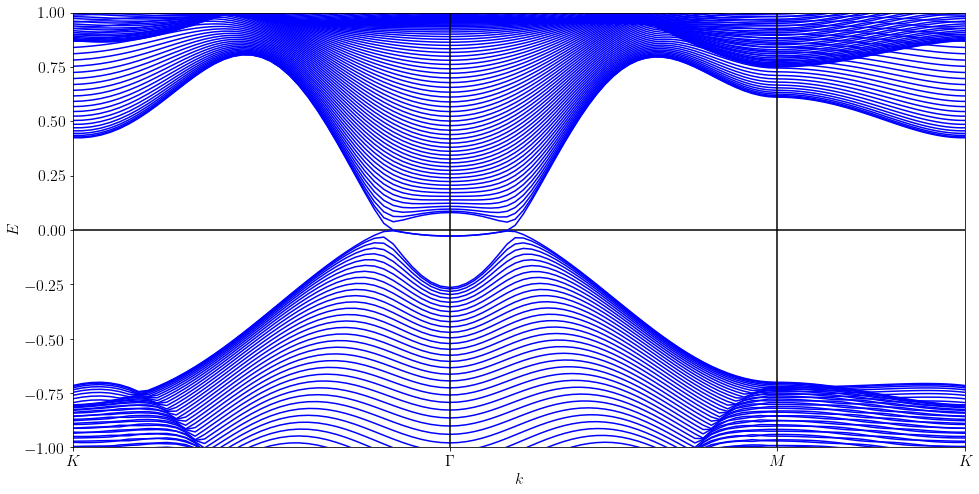

In [51]:
tools.plot_bands_2D(k_line, energies, k_labels, ymin=-1, ymax=1, linecolor='b', figsize=(16,8))

-0.027754528937139155
-0.027754523775114618


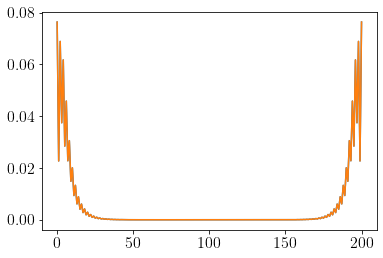

In [53]:
i=40

zs = np.linspace(0, Lz-0.5 , 2*Lz-1)
densities1 = tools.density(evecs[i,:,Lz-1],1)
densities2 = tools.density(evecs[i,:,Lz],1)
densities3 = tools.density(evecs[i,:,Lz+1],1)


#plt.plot(densities1)
plt.plot(densities2)
plt.plot(densities3)

#print(energies[i,Lz-1])
print(energies[i,Lz])
print(energies[i,Lz+1])

### With strain

In [54]:
Lz=200
R= 800 #1e8
mu = 6.582
termination = 'p'
alpha = 0.

params = dict(Lz=Lz, R=R, mu=mu, hopping_data=hopping_data, alpha=alpha, termination=termination)

In [55]:
# check hermiticity at random momentum
kx = 2*np.random.random_sample()-1
ky = 2*np.random.random_sample()-1

#print(np.imag(hamiltonian_slab(kx, ky, L, R, mu, hopping_data)))

print(hamiltonian_strained_slab(kx, ky, Lz, R, mu, hopping_data, alpha, termination) 
      - np.transpose(np.conj(hamiltonian_strained_slab(kx, ky, Lz, R, mu, hopping_data, alpha, termination))))

[[0.+0.00000000e+00j 0.+0.00000000e+00j 0.+0.00000000e+00j ...
  0.+0.00000000e+00j 0.+0.00000000e+00j 0.+0.00000000e+00j]
 [0.+0.00000000e+00j 0.+0.00000000e+00j 0.+0.00000000e+00j ...
  0.+0.00000000e+00j 0.+0.00000000e+00j 0.+0.00000000e+00j]
 [0.+0.00000000e+00j 0.+0.00000000e+00j 0.+0.00000000e+00j ...
  0.+0.00000000e+00j 0.+0.00000000e+00j 0.+0.00000000e+00j]
 ...
 [0.+0.00000000e+00j 0.+0.00000000e+00j 0.+0.00000000e+00j ...
  0.+0.00000000e+00j 0.+0.00000000e+00j 0.+0.00000000e+00j]
 [0.+0.00000000e+00j 0.+0.00000000e+00j 0.+0.00000000e+00j ...
  0.+0.00000000e+00j 0.+1.73472348e-18j 0.+0.00000000e+00j]
 [0.+0.00000000e+00j 0.+0.00000000e+00j 0.+0.00000000e+00j ...
  0.+0.00000000e+00j 0.+0.00000000e+00j 0.+0.00000000e+00j]]


In [56]:
# reciprocal lattice vectors (hexagonal system)
b1 = np.array([0.891864, 0.514918])
b2 = np.array([0, 1.029836])
k_basis = np.array([b1,b2])

In [57]:
# define high-symmetry points for the band plot
Gamma = np.array([0,0]) @ k_basis
K = np.array([1/3,1/3]) @ k_basis
M = np.array([0,1/2]) @ k_basis

In [58]:
k_points = [K*0.6, Gamma, M*0.7]
k_labels = ['$K$', '$\Gamma$', '$M$']
k_line3, energies3, evecs3 = tools.compute_bands_2D(hamiltonian_strained_slab, params, k_points,Nk=100)

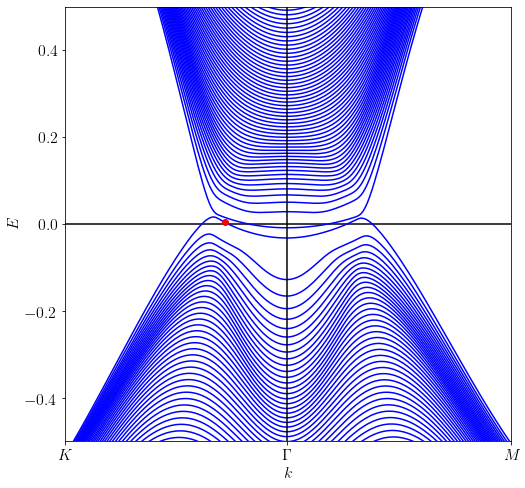

In [59]:
i=72

tools.plot_bands_2D(k_line3, energies3, k_labels, ymin=-0.5, ymax=0.5, linecolor='b', figsize=(8,8))
plt.plot(k_line3[i],energies3[i,Lz], marker='o', c='red')

In [61]:
evecs_flat = evecs3[:,:,Lz:Lz+2]

0.004222834388416903
0.015392267060812823


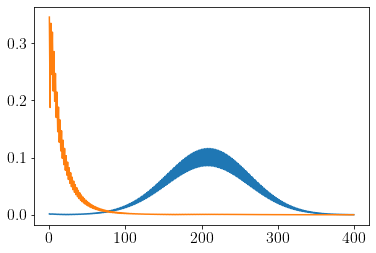

In [62]:
zs = np.linspace(0, Lz-0.5 , 2*Lz-1)
densities1 = tools.density(evecs3[i,:,Lz],1)
densities2 = tools.density(evecs3[i,:,Lz+1],1)

plt.plot(np.sqrt(densities1))
plt.plot(np.sqrt(densities2))

print(energies3[i,Lz])
print(energies3[i,Lz+1])

#### Save to file for figures

In [682]:
params = dict(R=R, Lz=Lz, mu=mu, termination=termination, alpha=alpha)

In [683]:
# Write everything to a pickle file
#path = os.path.dirname(os.getcwd()) + '/data/'
#out_name = 'CaAgP_LL_spectrum'
#fp = open(path + out_name + '.p', 'wb')
pickle.dump(params, fp)
pickle.dump(k_line3, fp)
pickle.dump(energies3, fp)
pickle.dump(evecs_flat, fp)
#fp.close()